In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler


In [26]:
import sys, pandas, numpy
print(sys.executable)
print(pandas.__version__, numpy.__version__)

/Users/mandarjoshi/anaconda3/bin/python
3.0.1 1.26.4


In [27]:
#The parameters for the synthetic GBM price data
days = 1000
mu = 0.05 #Drift (average rate of return)
sigma = 0.2 #Volatility (standard deviation)
S0 = 100 #Initial Price
dt = 1/252 #Time step (1 day)

In [28]:
#Generate the data using GBM
np.random.seed(42)
prices = np.zeros(days)
prices[0] = S0
for t in range(1, days):
    #Daily return using random normal distribution
    daily_return = np.random.normal(mu * dt, sigma * np.sqrt(dt))
    prices[t] = prices[t-1] * (1 + daily_return)

#Convert to a DataFrame to have an easier time in handling the data
df = pd.DataFrame(prices, columns = ['Close'])

Geometric Brownian Motion (GBM) is a continuous‑time stochastic process where the log of the price follows Brownian motion with drift. It’s a standard model in financial math used to simulate synthetic price paths.

Key components of GBM:
Drift (mu): The deterministic, expected return or trend over time.
Volatility (sigma): Random fluctuations (“noise”), usually the standard deviation of returns.

Multiplicative growth: Changes are proportional to the current price (dS/S), so the price stays positive.


In [29]:
from sklearn.preprocessing import MinMaxScaler

#Train/test split on raw series to avoid leakage of training data into test set
split_idx = int(len(df) * 0.8)
train_raw = df['Close'].values[:split_idx].reshape(-1, 1)
test_raw = df['Close'].values[split_idx:].reshape(-1, 1)

#Normalise using only the training data
scaler = MinMaxScaler(feature_range = (0,1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

In [30]:
#Create sliding window sequences:
def create_sequences(data, time_steps):
    X, y = [], [ ] #Initialising empty lists for sequences and targets
    for i in range (len(data) - time_steps):
        X.append(data[i:(i +time_steps), 0]) #Appending the sequence of data
        y.append(data[i + time_steps, 0]) #Appending the target value
    return np.array(X), np.array(y)

TIME_STEPS = 60 #Sequence length

#Sequences for training data
X_train, y_train = create_sequences(train_scaled, TIME_STEPS)

#For test sequences, provide the last 60 days of training data at the start of the test data, so the first test prediction has context of the last 60 days of training data
test_input = np.concatenate([train_scaled[-TIME_STEPS:], test_scaled], axis=0)
X_test, y_test = create_sequences(test_input, TIME_STEPS)

#Reshape for LSTM input: (samples, time_steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

#Targets are 2D
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)


create_sequences
This function builds supervised learning samples from a 1D time series by sliding a fixed-size window across the data. For each index i, it takes the previous time_steps values as the input sequence X[i] and the immediately following value as the target y[i]. This turns a continuous series into many (sequence -> next value) pairs that the LSTM can learn from.

In [31]:
#Defining the LSTM model:
class LSTMModel(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 64, num_layers = 2, output_size = 1):
        super(LSTMModel, self).__init__()

        #LSTM layers --> 2 stacked layers with hidden size 64
        #Hidden size is the number of units in the LSTM's internal state, memory. How many features the model keeps track of at each time step.
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first = True, dropout = 0.2)

        #Fully connected output layer - maps hidden state to single price prediction
        self.fc = nn.Linear(hidden_size, output_size) #is a fully connected layer that takes the LSTM's last hidden state (size hidden_size) and maps it to a single scalar prediction (output_size = 1)

    def forward(self, x):
        #Run input through LSTM layers
        lstm_out, _ =  self.lstm(x)

        #Take only the last time step's output for prediction
        out = self.fc(lstm_out[:, -1, :])
        return out

#Convert numpy arrays to PyTorch tensors
torch.manual_seed(42)
X_train_tensor = torch.tensor(X_train, dtype = torch.float32) #Use .tensor() to convert numpy arrays to PyTorch tensors
y_train_tensor = torch.tensor(y_train, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.float32)

#Initialise model, loss function and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #check if CUDA is available
model = LSTMModel().to(device)
criterion = nn.MSELoss() #Mean Squared Error Loss
optimizer = torch.optim.Adam(model.parameters(), lr =0.001) #Using Adam which is a popular optimization algorithm for training neural networks

print(model)
print(f"Training on: {device}")
print(f"Train size: {len(X_train_tensor)}, Test size: {len(X_test_tensor)}")


LSTMModel(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Training on: cpu
Train size: 740, Test size: 200


LSTMModel class
The model defines a 2-layer LSTM with hidden size 64 and dropout 0.2, followed by a fully connected layer that maps the final LSTM hidden state to a single scalar prediction. In forward, it runs the input through the LSTM, takes the output at the last time step (so it predicts the next value from the full window), and then applies the linear layer to produce the final forecast.

In [32]:
#Making the training loop and showing the losses
EPOCHS = 50 #Number of epochs to train the model
BATCH_SIZE = 32 #Number of samples in each mini-batch
train_losses = [] #To store training loss for EACH epoch
val_losses = [] #To store validation loss for EACH epoch

#Create a simple validation split from the end of the training data
val_split = int(len(X_train_tensor) * 0.9)
X_train_final = X_train_tensor[:val_split]
y_train_final = y_train_tensor[:val_split]
X_val = X_train_tensor[val_split:]
y_val = y_train_tensor[val_split:]

# Create DataLoader for mini-batch training
#DataLoader is a PyTorch helper that allows you to load data in batches from a dataset. It helps in managing the data loading process efficiently.
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_final, y_train_final)
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = False) #order matters, so for time series need to keep shuffle as False

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0 # Variable to store the loss for the current epoch

    for X_batch, y_batch in train_loader:
        #Move batch to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        #Forward pass
        predictions = model(X_batch) #Predictions from the model
        loss = criterion(predictions, y_batch) #Computing the error (loss) between the predicted and actual values

        #Backward pass
        optimizer.zero_grad() #Resetting the gradients to zero before computing the new gradients
        loss.backward() 
        optimizer.step() #Updating the model parameters based on the computed gradients
        epoch_loss += loss.item() * len(X_batch) #Accumulating the loss for the current epoch

    #Average loss for this epoch
    avg_loss = epoch_loss / len(X_train_final) #Calculating the average loss for the current epoch
    train_losses.append(avg_loss) # Adding the average loss to the training losses list

    #Validation loss
    model.eval()
    with torch.no_grad(): #Tells PyTorch to not track gradients for this block
        X_val_device = X_val.to(device)
        y_val_device = y_val.to(device)
        val_preds = model(X_val_device)
        val_loss = criterion(val_preds, y_val_device).item()
    val_losses.append(val_loss) #Adding the validation loss to the respective list
    model.train()

    # Print progress after 10 epochs interval
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_loss:.6f} - Val Loss: {val_loss:.6f}") #Printing the loss for the current epoch
print("Training complete!")

Epoch [10/50] - Train Loss: 0.007607 - Val Loss: 0.004806
Epoch [20/50] - Train Loss: 0.004328 - Val Loss: 0.002523
Epoch [30/50] - Train Loss: 0.003808 - Val Loss: 0.002192
Epoch [40/50] - Train Loss: 0.003752 - Val Loss: 0.001925
Epoch [50/50] - Train Loss: 0.003032 - Val Loss: 0.001770
Training complete!


Training loop and loss code
The training loop iterates over epochs and mini-batches from a DataLoader. For each batch, it runs a forward pass, computes MSE loss, backpropagates, and updates weights via Adam. It accumulates the batch losses scaled by batch size, then computes an average epoch loss by dividing by the training size. After each epoch it evaluates validation loss on the held-out tail of the training data. Every 10 epochs it prints both train and validation loss using :.6f, which formats the float to 6 decimal places.

In [33]:
#Making the visualizations and the metrics:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    #Move test data to device and get predictions
    X_test_device = X_test_tensor.to(device)
    test_preds = model(X_test_device).cpu().numpy() #Moving the predictions to the CPU and converting to a numpy array

#Inverse transform predictions and actual values back to original price scale
test_preds_actual = scaler.inverse_transform(test_preds)
y_test_actual = scaler.inverse_transform(y_test_tensor.cpu().numpy())

#Calculating the metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, test_preds_actual)) #RMSE is the square root of the mean squared error, which is a measure of the average squared difference between the predicted and actual values
mae = mean_absolute_error(y_test_actual, test_preds_actual) #MAE is the average ABSOLUTE DIFFERENCE between the predicted and actual values
r2 = r2_score(y_test_actual, test_preds_actual) #R² indicates how well the predictions explain the variance in the true values
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²:   {r2:.4f}")


RMSE: 4.2937
MAE: 3.4597
R²:   0.9479


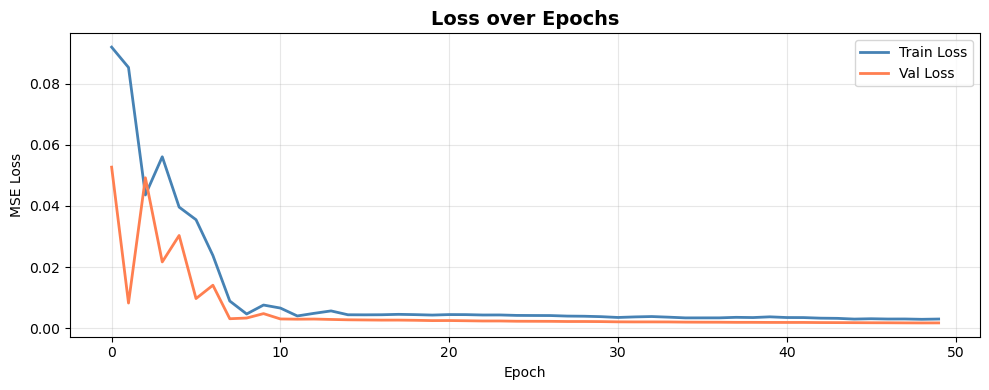

In [34]:
#First Plot: Showing the trend of the training and validation loss over the epochs
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label = 'Train Loss', color = 'steelblue', linewidth = 2)
plt.plot(val_losses, label = 'Val Loss', color = 'coral', linewidth = 2)
plt.title('Loss over Epochs', fontsize = 14, fontweight = 'bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

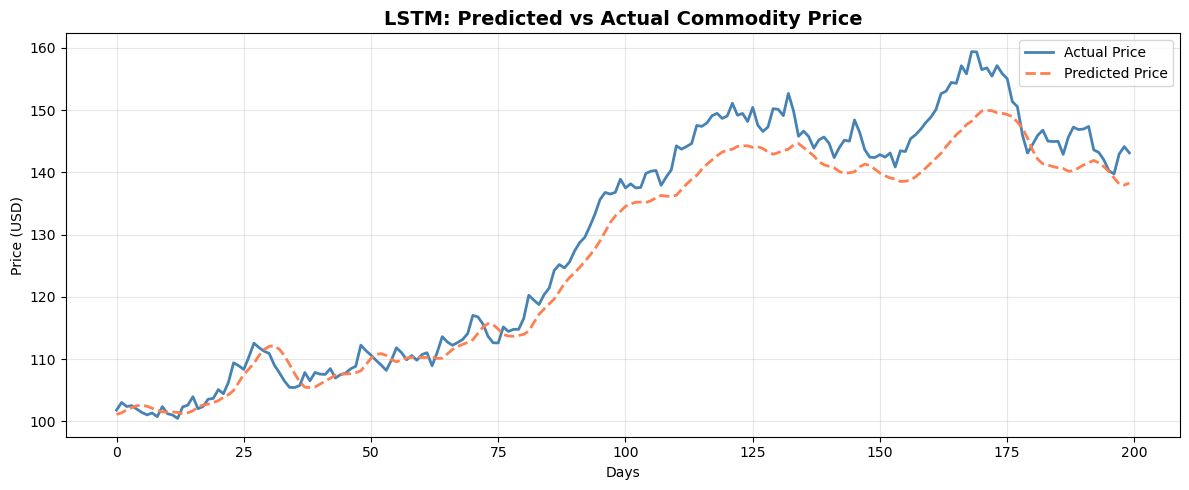

In [35]:
#Second Plot: Predicted vs Actual Prices
plt.figure(figsize = (12,5))
plt.plot(y_test_actual, label = 'Actual Price', color = 'steelblue', linewidth = 2)
plt.plot(test_preds_actual, label = 'Predicted Price', color = 'coral', linewidth = 2, linestyle = '--')
plt.title('LSTM: Predicted vs Actual Commodity Price', fontsize = 14, fontweight = 'bold')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()